In [130]:
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas
import pandas as pd
from chainconsumer import Chain, ChainConsumer, PlotConfig
from numpyro.infer import MCMC, NUTS

In [142]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

in_flag = True  # True for in-situ, False for ex-situ
snapz0 = 600

In [143]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = np.array(pub_data["time_Gyr"])[-1]
timez0

np.float64(13.798746883)

In [144]:
prop_dict = {"mfor": np.array([]), "mz0": np.array([]), "pz0": np.array([]), "age": np.array([])}

# for it_id in ["it001"]:
for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    smsk = src_dat["s_flag"][()].astype(bool)
    if in_flag:
        amsk = src_dat["grpid"][()] == 0
    else:
        amsk = src_dat["grpid"][()] != 0
    msk = smsk & amsk

    mfor = 10 ** src_dat["logm_tfor"][msk]
    mz0 = 10 ** src_dat["logm_tz0"][msk]
    pz0 = src_dat["torb_600"][msk]
    age = timez0 - src_dat["tfor"][msk]

    prop_dict["mfor"] = np.append(prop_dict["mfor"], mfor)
    prop_dict["mz0"] = np.append(prop_dict["mz0"], mz0)
    prop_dict["pz0"] = np.append(prop_dict["pz0"], pz0)
    prop_dict["age"] = np.append(prop_dict["age"], age)

In [145]:
def gc_forward_model(mfor, mz0, pz0, age):
    """
    Forward model with anchored lifetime mass loss
    and zero-mean age/orbital modulation.
    """

    # -------- log-transform --------
    log_mfor = jnp.log10(mfor)
    log_mz0 = jnp.log10(mz0)
    log_age = jnp.log10(age)
    log_pz0 = jnp.log10(pz0)

    # -------- anchored lifetime loss --------
    delta = numpyro.sample("delta", dist.Normal(0.6, 0.4))
    # delta ~ typical log10(m_for / m_z0)

    # -------- modulation parameters (zero-mean) --------
    a = numpyro.sample("a", dist.Normal(0.0, 0.3))
    b = numpyro.sample("b", dist.Normal(0.0, 0.3))

    # Intrinsic scatter
    sigma_int = numpyro.sample("sigma_int", dist.HalfNormal(0.3))

    # -------- deterministic prediction --------
    modulation = a * (log_age - jnp.mean(log_age)) + b * (log_pz0 - jnp.mean(log_pz0))

    log_mz0_model = log_mfor - delta - modulation

    # -------- likelihood --------
    with numpyro.plate("gc", len(mz0)):
        numpyro.sample("mz0_obs", dist.Normal(log_mz0_model, sigma_int), obs=log_mz0)


In [146]:
# Set up HMC
nuts_kernel = NUTS(gc_forward_model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000)

# Run inference
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, mfor=prop_dict["mfor"], mz0=prop_dict["mz0"], pz0=prop_dict["pz0"], age=prop_dict["age"])

# Extract posterior samples
posterior = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████| 11000/11000 [00:05<00:00, 1969.81it/s, 3 steps of size 6.91e-01. acc. prob=0.88]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.36      0.07      0.36      0.25      0.47   6162.87      1.00
          b     -0.11      0.01     -0.11     -0.12     -0.09   7287.35      1.00
      delta      0.73      0.00      0.73      0.73      0.74  16250.46      1.00
  sigma_int      0.34      0.00      0.34      0.34      0.35   8206.22      1.00

Number of divergences: 0


In [148]:
df = pd.DataFrame(
    {
        "a": posterior["a"],
        "b": posterior["b"],
        "delta": posterior["delta"],
        "sigma_int": posterior["sigma_int"],
    }
)


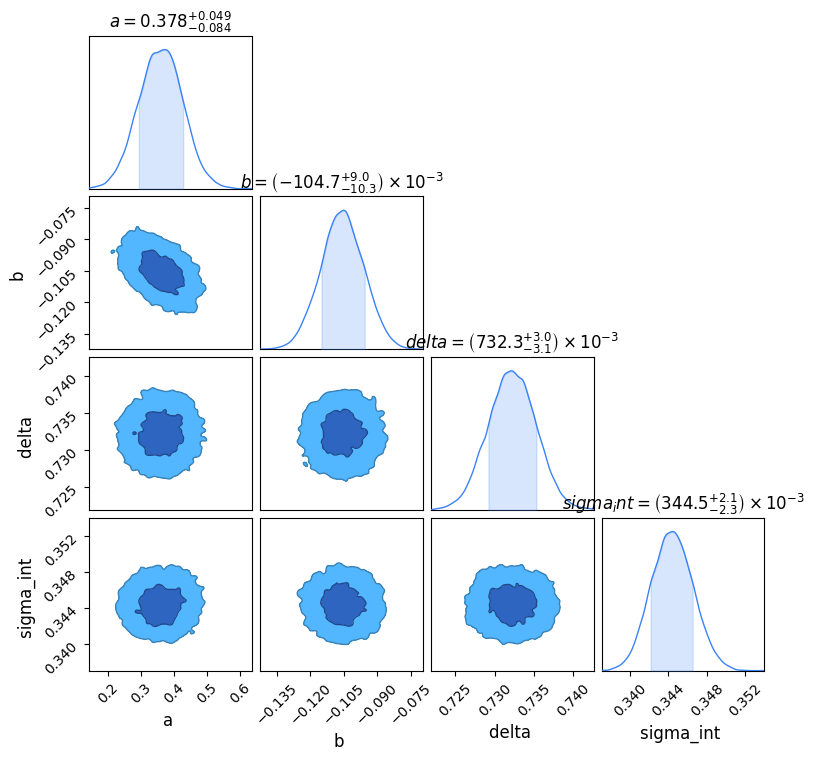

In [137]:
C = ChainConsumer()

C.add_chain(Chain(samples=df, name="Forward model (simulation-calibrated)"))

C.set_plot_config(
    PlotConfig(
        diagonal_tick_labels=True,
        shade=True,
        shade_alpha=0.4,
        sigma2d=True,
        flip=False,
    )
)

fig = C.plotter.plot(figsize=(8, 8))

In [149]:
summary = C.analysis.get_summary()
print(summary)

{'Forward model (simulation-calibrated)': {'a': Bound(lower=0.29370598669112313, center=0.37785872252683206, upper=0.42732589593982273), 'b': Bound(lower=-0.11499652451738773, center=-0.104655690047375, upper=-0.09562198353003243), 'delta': Bound(lower=0.7292074140827087, center=0.7323189562103432, upper=0.7352845805763778), 'sigma_int': Bound(lower=0.34213863467916134, center=0.34446192463503633, upper=0.3465197440501017)}}


In [150]:
# samples = mcmc.get_samples()

# k = 0
# nsamp = 5000
# indices = np.random.randint(0, len(samples["delta"]), size=nsamp)

# log_age_mean = np.mean(np.log10(prop_dict["age"]))
# log_pz0_mean = np.mean(np.log10(prop_dict["pz0"]))

# log_mfor_obs = []

# for i in indices:
#     modulation = samples["a"][i] * (np.log10(prop_dict["age"][k]) - log_age_mean) + samples["b"][i] * (
#         np.log10(prop_dict["pz0"][k]) - log_pz0_mean
#     )

#     log_mfor = (
#         np.log10(prop_dict["mz0"][k])
#         + samples["delta"][i]
#         + modulation
#         - np.random.normal(0, samples["sigma_int"][i])
#     )

#     log_mfor_obs.append(log_mfor)

# log_mfor_obs = np.array(log_mfor_obs)
# plt.hist(log_mfor_obs, bins=30)
# plt.axvline(np.log10(prop_dict["mfor"][k]), color="k", lw=2)
# plt.xlabel(r"$\log_{10}(M_{\rm for})$")

In [98]:
n = 100

mass_dict = {"mean": [], "median": [], "std": [], "per25": [], "per75": []}

for k in range(0, len(prop_dict["mfor"])):
    print(k + 1, "/", len(prop_dict["mfor"]))

    indices = np.random.randint(0, len(samples["a"]), size=n)

    log_mfors = []
    for i in indices:
        modulation = samples["a"][i] * (np.log10(prop_dict["age"][k]) - log_age_mean) + samples["b"][i] * (
            np.log10(prop_dict["pz0"][k]) - log_pz0_mean
        )

        log_mfor = (
            np.log10(prop_dict["mz0"][k])
            + samples["delta"][i]
            + modulation
            - np.random.normal(0, samples["sigma_int"][i])
        )

        log_mfors.append(log_mfor)

    log_mfors = np.array(log_mfors)

    mass_dict["mean"].append(np.mean(log_mfors))
    mass_dict["median"].append(np.median(log_mfors))
    mass_dict["std"].append(np.std(log_mfors))
    mass_dict["per25"].append(np.percentile(log_mfors, 25))
    mass_dict["per75"].append(np.percentile(log_mfors, 75))

1 / 99
2 / 99
3 / 99
4 / 99
5 / 99
6 / 99
7 / 99
8 / 99
9 / 99
10 / 99
11 / 99
12 / 99
13 / 99
14 / 99
15 / 99
16 / 99
17 / 99
18 / 99
19 / 99
20 / 99
21 / 99
22 / 99
23 / 99
24 / 99
25 / 99
26 / 99
27 / 99
28 / 99
29 / 99
30 / 99
31 / 99
32 / 99
33 / 99
34 / 99
35 / 99
36 / 99
37 / 99
38 / 99
39 / 99
40 / 99
41 / 99
42 / 99
43 / 99
44 / 99
45 / 99
46 / 99
47 / 99
48 / 99
49 / 99
50 / 99
51 / 99
52 / 99
53 / 99
54 / 99
55 / 99
56 / 99
57 / 99
58 / 99
59 / 99
60 / 99
61 / 99
62 / 99
63 / 99
64 / 99
65 / 99
66 / 99
67 / 99
68 / 99
69 / 99
70 / 99
71 / 99
72 / 99
73 / 99
74 / 99
75 / 99
76 / 99
77 / 99
78 / 99
79 / 99
80 / 99
81 / 99
82 / 99
83 / 99
84 / 99
85 / 99
86 / 99
87 / 99
88 / 99
89 / 99
90 / 99
91 / 99
92 / 99
93 / 99
94 / 99
95 / 99
96 / 99
97 / 99
98 / 99
99 / 99


In [140]:
diff = (prop_dict["mfor"] - 10 ** np.array(mass_dict["mean"])) / prop_dict["mfor"]
plt.hist(diff)

ValueError: operands could not be broadcast together with shapes (12483,) (99,) 

ValueError: x and y must be the same size

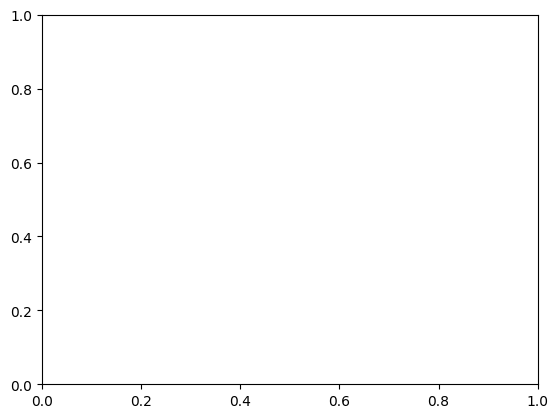

In [141]:
plt.scatter(np.log10(prop_dict["mz0"]), diff)
plt.xlabel("log Mass (z=0)")
plt.ylabel(r"Formation Mass" + "\n" + "(fractional difference model vs expected)")

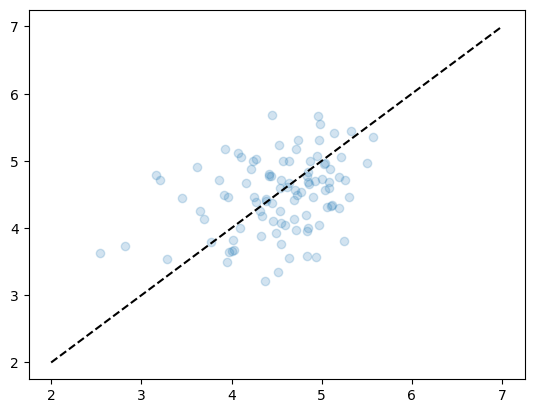

In [101]:
i = np.random.choice(len(samples["delta"]))

mod = samples["a"][i] * (np.log10(age) - log_age_mean) + samples["b"][i] * (np.log10(pz0) - log_pz0_mean)

log_mz0_pp = (
    np.log10(mfor) - samples["delta"][i] - mod + np.random.normal(0, samples["sigma_int"][i], size=len(mfor))
)

plt.scatter(np.log10(mz0), log_mz0_pp, alpha=0.2)
plt.plot([2, 7], [2, 7], "k--")

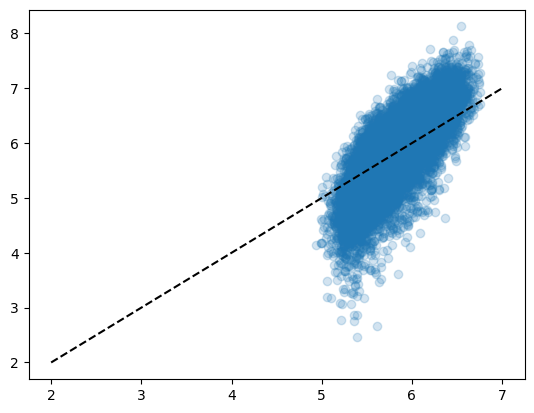

In [151]:
samples = mcmc.get_samples()

mfor = prop_dict["mfor"]
age = prop_dict["age"]
pz0 = prop_dict["pz0"]
mz0 = prop_dict["mz0"]

log_age_mean = np.mean(np.log10(age))
log_pz0_mean = np.mean(np.log10(pz0))

i = np.random.choice(len(samples["delta"]))

mod = samples["a"][i] * (np.log10(age) - log_age_mean) + samples["b"][i] * (np.log10(pz0) - log_pz0_mean)

# log_mz0_pp = (
#     np.log10(mfor) - samples["delta"][i] - mod + np.random.normal(0, samples["sigma_int"][i], size=len(mfor))
# )

log_mfor_pp = (
    np.log10(mz0) + samples["delta"][i] + mod - np.random.normal(0, samples["sigma_int"][i], size=len(mfor))
)

plt.scatter(np.log10(mfor), log_mfor_pp, alpha=0.2)
plt.plot([2, 7], [2, 7], "k--")

In [122]:
log_mz0 = np.log10(prop_dict["mz0"])
log_mfor = np.log10(prop_dict["mfor"])
log_age = np.log10(prop_dict["age"])
log_pz0 = np.log10(prop_dict["pz0"])

# Define slices exactly like your plot
bins = np.arange(4.5, 6.5, 0.2)
slice_id = np.digitize(log_mz0, bins) - 1
n_slices = bins.size - 1

log_age_mean = log_age.mean()
log_pz0_mean = log_pz0.mean()


def slice_conditional_model(log_mfor, log_mz0, log_age, log_pz0, slice_id, n_slices):
    # Hyperpriors: how slice coefficients vary across M_z0
    mu_delta = numpyro.sample("mu_delta", dist.Normal(0.7, 0.3))
    mu_alpha = numpyro.sample("mu_alpha", dist.Normal(0.0, 0.3))
    mu_beta = numpyro.sample("mu_beta", dist.Normal(0.0, 0.3))

    sig_delta = numpyro.sample("sig_delta", dist.HalfNormal(0.2))
    sig_alpha = numpyro.sample("sig_alpha", dist.HalfNormal(0.2))
    sig_beta = numpyro.sample("sig_beta", dist.HalfNormal(0.2))

    # Slice-level coefficients (this IS your plot logic)
    with numpyro.plate("slice", n_slices):
        delta = numpyro.sample("delta", dist.Normal(mu_delta, sig_delta))
        alpha = numpyro.sample("alpha", dist.Normal(mu_alpha, sig_alpha))
        beta = numpyro.sample("beta", dist.Normal(mu_beta, sig_beta))

    sigma = numpyro.sample("sigma", dist.HalfNormal(0.3))

    # Likelihood: conditional on M_z0
    mu = (
        log_mz0
        + delta[slice_id]
        + alpha[slice_id] * (log_pz0 - log_pz0_mean)
        + beta[slice_id] * (log_age - log_age_mean)
    )

    numpyro.sample("obs", dist.Normal(mu, sigma), obs=log_mfor)

In [123]:
nuts = NUTS(slice_conditional_model)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=4000)

mcmc.run(
    jax.random.PRNGKey(0),
    log_mfor=log_mfor,
    log_mz0=log_mz0,
    log_age=log_age,
    log_pz0=log_pz0,
    slice_id=slice_id,
    n_slices=n_slices,
)

samples = mcmc.get_samples()
mcmc.print_summary()


sample: 100%|██████████| 5000/5000 [00:17<00:00, 280.36it/s, 31 steps of size 1.76e-01. acc. prob=0.88]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
   alpha[0]     -0.11      0.01     -0.11     -0.14     -0.09   1713.91      1.00
   alpha[1]     -0.12      0.01     -0.11     -0.14     -0.09   1589.62      1.00
   alpha[2]     -0.11      0.01     -0.11     -0.13     -0.09   2156.06      1.00
   alpha[3]     -0.10      0.02     -0.10     -0.13     -0.08   2384.72      1.00
   alpha[4]     -0.10      0.02     -0.10     -0.13     -0.08   2902.41      1.00
   alpha[5]     -0.10      0.02     -0.11     -0.14     -0.07   2650.65      1.00
   alpha[6]     -0.10      0.03     -0.11     -0.14     -0.07   2062.77      1.00
   alpha[7]     -0.11      0.02     -0.11     -0.15     -0.07   2093.27      1.00
   alpha[8]     -0.10      0.01     -0.10     -0.11     -0.08   1372.95      1.00
    beta[0]      0.93      0.14      0.93      0.71      1.17   2945.93      1.00
    beta[1]      0.71      0.14      0.71      0.46      0.93   2614.06      1.00
    beta[2]    

In [125]:
def predict_log_mfor(samples, log_mz0_obs, log_pz0_obs, log_age_obs, slice_idx):
    n = len(samples["sigma"])
    idx = np.random.randint(0, n, size=n)

    return (
        log_mz0_obs
        + samples["delta"][idx, slice_idx]
        + samples["alpha"][idx, slice_idx] * (log_pz0_obs - log_pz0_mean)
        + samples["beta"][idx, slice_idx] * (log_age_obs - log_age_mean)
        + np.random.normal(0, samples["sigma"][idx])
    )


# Example GC
# k = 1
log_mfors = []
for k in range(0, len(prop_dict["age"])):
    print(k + 1, "/", len(prop_dict["mfor"]))
    log_mfor_post = predict_log_mfor(samples, log_mz0[k], log_pz0[k], log_age[k], slice_id[k])
    log_mfors.append(np.mean(log_mfor_post))

# np.percentile(log_mfor_post, [16, 50, 84])

# np.mean(log_mfor_post), np.log10(prop_dict["mfor"][k])

1 / 8580
2 / 8580
3 / 8580
4 / 8580
5 / 8580
6 / 8580
7 / 8580
8 / 8580
9 / 8580
10 / 8580
11 / 8580
12 / 8580
13 / 8580
14 / 8580
15 / 8580
16 / 8580
17 / 8580
18 / 8580
19 / 8580
20 / 8580
21 / 8580
22 / 8580
23 / 8580
24 / 8580
25 / 8580
26 / 8580
27 / 8580
28 / 8580
29 / 8580
30 / 8580
31 / 8580
32 / 8580
33 / 8580
34 / 8580
35 / 8580
36 / 8580
37 / 8580
38 / 8580
39 / 8580
40 / 8580
41 / 8580
42 / 8580
43 / 8580
44 / 8580
45 / 8580
46 / 8580
47 / 8580
48 / 8580
49 / 8580
50 / 8580
51 / 8580
52 / 8580
53 / 8580
54 / 8580
55 / 8580
56 / 8580
57 / 8580
58 / 8580
59 / 8580
60 / 8580
61 / 8580
62 / 8580
63 / 8580
64 / 8580
65 / 8580
66 / 8580
67 / 8580
68 / 8580
69 / 8580
70 / 8580
71 / 8580
72 / 8580
73 / 8580
74 / 8580
75 / 8580
76 / 8580
77 / 8580
78 / 8580
79 / 8580
80 / 8580
81 / 8580
82 / 8580
83 / 8580
84 / 8580
85 / 8580
86 / 8580
87 / 8580
88 / 8580
89 / 8580
90 / 8580
91 / 8580
92 / 8580
93 / 8580
94 / 8580
95 / 8580
96 / 8580
97 / 8580
98 / 8580
99 / 8580
100 / 8580
101 / 85

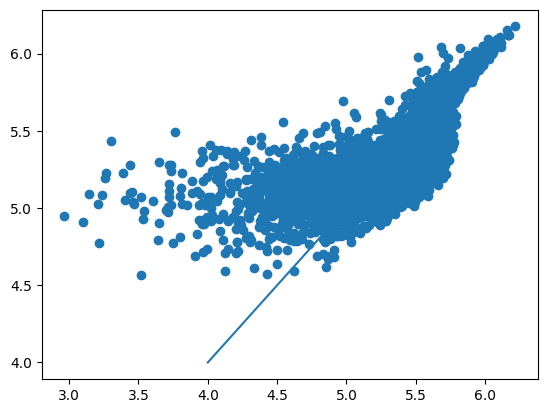

In [126]:
plt.scatter(log_mfors, np.log10(prop_dict["mfor"]))
plt.plot([4, 6], [4, 6])